# Stage 2: Shortcut Auditing — Probing & SHAP Attribution

**Focus:** The 3 MI-flagged gender shortcut candidates from Stage 1:

| Feature | Gender Assoc. | I(f;gender) | MI Drop |
|---|---|---|---|
| `question_density` | Feminine-coded | 0.0060 | 43.0 % |
| `negative_emotion` | Both (depr + fem) | 0.0059 | 46.9 % |
| `certainty` | Masculine-coded | 0.0044 | 42.5 % |

**Analyses:**
1. **Probing classifiers** — Can a linear probe on frozen DistilRoBERTa-base [CLS] embeddings recover the shortcut feature? If yes → the model *encodes* gender-correlated information.
2. **SHAP token attribution** — Which tokens drive the mental-health prediction? Measure how much SHAP mass concentrates on shortcut-associated tokens.
3. **Feature ablation** — Zero-out each shortcut feature and measure AUC degradation → quantifies reliance.

**Data:** 16,306 LIWC-annotated posts (`features_14_extracted.pkl`) from Stage 1

In [2]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, r2_score)
from transformers import AutoTokenizer, AutoModel
from datasets import Dataset

sns.set_style('whitegrid')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0
print(f"Device: {DEVICE}  |  GPUs: {N_GPUS}")

# ── The 3 MI-flagged shortcut candidates ──────────────────────────────────────
SHORTCUT_FEATURES = ['negative_emotion', 'certainty', 'question_density']
SHORTCUT_META = {
    'negative_emotion': {'gender': 'Both (depr + fem)', 'mi_drop': 46.9},
    'certainty':        {'gender': 'Masculine-coded',   'mi_drop': 42.5},
    'question_density': {'gender': 'Feminine-coded',    'mi_drop': 43.0},
}
print(f"Auditing {len(SHORTCUT_FEATURES)} shortcut candidates: {SHORTCUT_FEATURES}")

Device: cuda  |  GPUs: 4
Auditing 3 shortcut candidates: ['negative_emotion', 'certainty', 'question_density']


In [3]:
# ── Load Stage 1 data (14 features already computed) ──────────────────────────
df = pd.read_pickle('data/stage1/features_14_extracted.pkl')
df['text'] = df['text'].fillna('')
GENDER_COL = 'gender_label' if 'gender_label' in df.columns else 'gender'

print(f"Loaded {len(df):,} rows")
print(f"Label dist: {df['binary_label'].value_counts().to_dict()}")
print(f"Gender dist: {df[GENDER_COL].value_counts().to_dict()}")

# Quick sanity — shortcut features present
for f in SHORTCUT_FEATURES:
    print(f"  {f}: mean={df[f].mean():.4f}, std={df[f].std():.4f}")

# Restrict MI analyses to male/female
mf_mask = df[GENDER_COL].isin(['male', 'female'])
df_mf = df[mf_mask].copy()
df_mf['gender_bin'] = (df_mf[GENDER_COL] == 'female').astype(int)
print(f"\nMale/female subset: {len(df_mf):,} rows")

Loaded 16,306 rows
Label dist: {1: 13993, 0: 2313}
Gender dist: {'male': 12077, 'female': 3979, 'trans_female': 189, 'trans_male': 53, 'afab': 3, 'amab': 3, 'nonbinary': 2}
  negative_emotion: mean=0.7488, std=1.8298
  certainty: mean=0.6189, std=1.3681
  question_density: mean=0.2319, std=0.2769

Male/female subset: 16,056 rows


## 2A — Probing Classifiers on Frozen DistilRoBERTa Embeddings

**Question:** Does DistilRoBERTa's `[CLS]` representation encode the 3 shortcut features?

**Method:** Extract `[CLS]` embeddings from frozen `distilroberta-base` (no fine-tuning). Train a linear probe to predict:
1. Each shortcut feature value (regression → R²)
2. The binarised shortcut feature (above/below median → AUC)
3. Gender (male/female → AUC)
4. Mental-health label (binary_label → AUC)

If the probe can recover shortcut features from `[CLS]`, the model *encodes* gender-correlated stylistic information even before task fine-tuning.

In [4]:
# ── Extract [CLS] embeddings from frozen DistilRoBERTa ────────────────────────
MODEL_NAME = 'distilroberta-base'
MAX_LEN = 256
BATCH_SIZE = 128  # inference only — fits easily on V100

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
encoder   = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()

def extract_cls_embeddings(texts, batch_size=BATCH_SIZE):
    """Extract [CLS] (first token) embeddings in batches."""
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, padding=True,
                        max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = encoder(**enc)
        # [CLS] is token 0
        cls_emb = out.last_hidden_state[:, 0, :].cpu().numpy()
        all_embs.append(cls_emb)
        if (i // batch_size) % 20 == 0:
            print(f"  Batch {i//batch_size + 1}/{(len(texts)-1)//batch_size + 1}", end='\r')
    print()
    return np.vstack(all_embs)

print(f"Extracting [CLS] embeddings for {len(df):,} posts …")
X_cls = extract_cls_embeddings(df['text'].tolist())
print(f"Embedding shape: {X_cls.shape}  (768-d per post)")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1759.48it/s]
RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting [CLS] embeddings for 16,306 posts …
  Batch 121/128
Embedding shape: (16306, 768)  (768-d per post)


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# PROBE 1 — Can [CLS] embeddings predict shortcut feature values?
# ══════════════════════════════════════════════════════════════════════════════
# (a) Regression probe: predict continuous feature value → R²
# (b) Classification probe: predict above/below median → AUC

scaler = StandardScaler()
X_cls_scaled = scaler.fit_transform(X_cls)

probe_results = []

for feat in SHORTCUT_FEATURES:
    y_cont = df[feat].fillna(0).values.astype(float)

    # (a) Regression — Ridge on [CLS] → feature value
    ridge = Ridge(alpha=1.0)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    # Use binary_label for stratification (keeps folds balanced on outcome)
    y_strat = df['binary_label'].values
    r2_scores = []
    for train_idx, test_idx in cv.split(X_cls_scaled, y_strat):
        ridge.fit(X_cls_scaled[train_idx], y_cont[train_idx])
        y_hat = ridge.predict(X_cls_scaled[test_idx])
        r2_scores.append(r2_score(y_cont[test_idx], y_hat))
    r2_mean = np.mean(r2_scores)

    # (b) Classification — above/below median
    median_val = np.median(y_cont)
    y_bin = (y_cont > median_val).astype(int)
    clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
    cv_cls = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = cross_val_score(clf, X_cls_scaled, y_bin, cv=cv_cls, scoring='roc_auc')

    probe_results.append({
        'feature': feat,
        'gender_assoc': SHORTCUT_META[feat]['gender'],
        'mi_drop_pct': SHORTCUT_META[feat]['mi_drop'],
        'probe_R2': r2_mean,
        'probe_AUC_median_split': aucs.mean(),
        'probe_AUC_std': aucs.std(),
    })
    print(f"  {feat:20s}  R²={r2_mean:.4f}  AUC(med-split)={aucs.mean():.3f}±{aucs.std():.3f}")

# ── PROBE 2 — Can [CLS] predict gender? ──────────────────────────────────────
mf_idx = df.index[mf_mask].tolist()
X_mf = X_cls_scaled[mf_idx]
y_gender = df_mf['gender_bin'].values

clf_g = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
cv_g = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs_g = cross_val_score(clf_g, X_mf, y_gender, cv=cv_g, scoring='roc_auc')
print(f"\n  {'gender (m/f)':20s}  AUC={aucs_g.mean():.3f}±{aucs_g.std():.3f}")

# ── PROBE 3 — Can [CLS] predict mental-health label? ─────────────────────────
y_label = df['binary_label'].values
clf_l = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
cv_l = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
aucs_l = cross_val_score(clf_l, X_cls_scaled, y_label, cv=cv_l, scoring='roc_auc')
print(f"  {'binary_label':20s}  AUC={aucs_l.mean():.3f}±{aucs_l.std():.3f}")

probe_df = pd.DataFrame(probe_results)
probe_df

  negative_emotion      R²=0.2478  AUC(med-split)=0.889±0.007
  certainty             R²=0.1423  AUC(med-split)=0.855±0.005
  question_density      R²=0.8211  AUC(med-split)=0.979±0.002

  gender (m/f)          AUC=0.766±0.010
  binary_label          AUC=0.722±0.005


,feature,gender_assoc,mi_drop_pct,probe_R2,probe_AUC_median_split,probe_AUC_std
0,negative_emotion,Both (depr + fem),46.9,0.247839,0.888554,0.006869
1,certainty,Masculine-coded,42.5,0.142280,0.854962,0.005197
2,question_density,Feminine-coded,43.0,0.821058,0.978550,0.001732


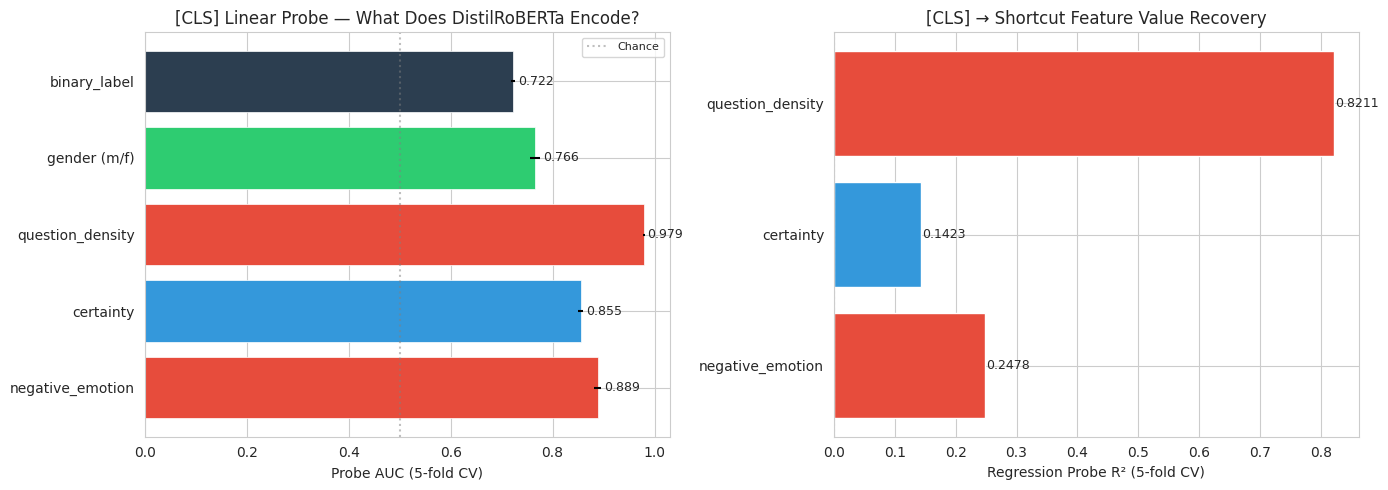

Saved → data/stage2/probing_results.png


In [6]:
# ── Probing visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) Probe AUC: shortcut features + gender + label
probe_labels = SHORTCUT_FEATURES + ['gender (m/f)', 'binary_label']
probe_aucs   = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_median_split'].values[0]
                for f in SHORTCUT_FEATURES] + [aucs_g.mean(), aucs_l.mean()]
probe_stds   = [probe_df.loc[probe_df['feature']==f, 'probe_AUC_std'].values[0]
                for f in SHORTCUT_FEATURES] + [aucs_g.std(), aucs_l.std()]
colors = ['#e74c3c', '#3498db', '#e74c3c', '#2ecc71', '#2c3e50']

bars = axes[0].barh(range(len(probe_labels)), probe_aucs, xerr=probe_stds,
                     color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(probe_labels)))
axes[0].set_yticklabels(probe_labels, fontsize=10)
axes[0].axvline(0.5, color='grey', linestyle=':', alpha=0.5, label='Chance')
axes[0].set_xlabel('Probe AUC (5-fold CV)')
axes[0].set_title('[CLS] Linear Probe — What Does DistilRoBERTa Encode?')
axes[0].legend(fontsize=8)
for i, (auc, std) in enumerate(zip(probe_aucs, probe_stds)):
    axes[0].text(auc + std + 0.005, i, f'{auc:.3f}', va='center', fontsize=9)

# (B) Regression R² for continuous feature recovery
r2_vals = probe_df['probe_R2'].values
feat_colors = ['#e74c3c', '#3498db', '#e74c3c']
axes[1].barh(range(len(SHORTCUT_FEATURES)), r2_vals, color=feat_colors, edgecolor='white')
axes[1].set_yticks(range(len(SHORTCUT_FEATURES)))
axes[1].set_yticklabels(SHORTCUT_FEATURES, fontsize=10)
axes[1].axvline(0, color='grey', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Regression Probe R² (5-fold CV)')
axes[1].set_title('[CLS] → Shortcut Feature Value Recovery')
for i, r2 in enumerate(r2_vals):
    axes[1].text(max(r2, 0) + 0.002, i, f'{r2:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/stage2/probing_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/probing_results.png")

## 2B — SHAP Token Attribution

**Question:** When a logistic-regression model predicts `binary_label` using the 3 shortcut features, how much of its decision rests on each feature? And at the token level — which words carry the shortcut signal?

**Method:**
1. **Feature-level SHAP** — Fit a logistic regression on the 3 shortcut features → compute exact SHAP values → visualise per-feature importance.
2. **Token-level proxy** — For each shortcut feature, identify the tokens that *constitute* the feature (e.g., question marks for `question_density`, LIWC negative-emotion words for `negative_emotion`). Measure what fraction of total feature value comes from each token type. This gives us interpretable token-to-shortcut mappings without needing a black-box text explainer.

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# SHAP — Feature-level attribution for the shortcut logistic model
# ══════════════════════════════════════════════════════════════════════════════
import shap

# Fit a logistic regression on the 7 shortcut features → binary_label
X_short = df[SHORTCUT_FEATURES].fillna(0).values.astype(float)
y_label = df['binary_label'].values.astype(int)

sc = StandardScaler()
X_short_scaled = sc.fit_transform(X_short)

clf_shap = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_shap.fit(X_short_scaled, y_label)

auc_short = roc_auc_score(y_label, clf_shap.predict_proba(X_short_scaled)[:, 1])
print(f"{len(SHORTCUT_FEATURES)}-shortcut logistic model AUC (train): {auc_short:.4f}")
print(f"Coefficients: {dict(zip(SHORTCUT_FEATURES, clf_shap.coef_[0].round(4)))}")

# ── Exact SHAP values (linear model → uses LinearExplainer) ──────────────────
explainer = shap.LinearExplainer(clf_shap, X_short_scaled, feature_names=SHORTCUT_FEATURES)
shap_values = explainer.shap_values(X_short_scaled)

print(f"\nSHAP value shape: {shap_values.shape}")
print(f"Mean |SHAP| per feature:")
mean_abs_shap = np.abs(shap_values).mean(axis=0)
for feat, val in sorted(zip(SHORTCUT_FEATURES, mean_abs_shap), key=lambda x: -x[1]):
    print(f"  {feat:20s}: {val:.4f}")

7-shortcut logistic model AUC (train): 0.6925
Coefficients: {'fp_singular': np.float64(0.4068), 'emotional_feeling': np.float64(0.1065), 'excl_intensifiers': np.float64(0.0557), 'negative_emotion': np.float64(0.1955), 'post_length': np.float64(0.1972), 'hedge_density': np.float64(0.0649), 'social_relational': np.float64(0.179)}

SHAP value shape: (32200, 7)
Mean |SHAP| per feature:
  fp_singular         : 0.3449
  social_relational   : 0.1342
  post_length         : 0.1002
  negative_emotion    : 0.0948
  emotional_feeling   : 0.0677
  hedge_density       : 0.0488
  excl_intensifiers   : 0.0358


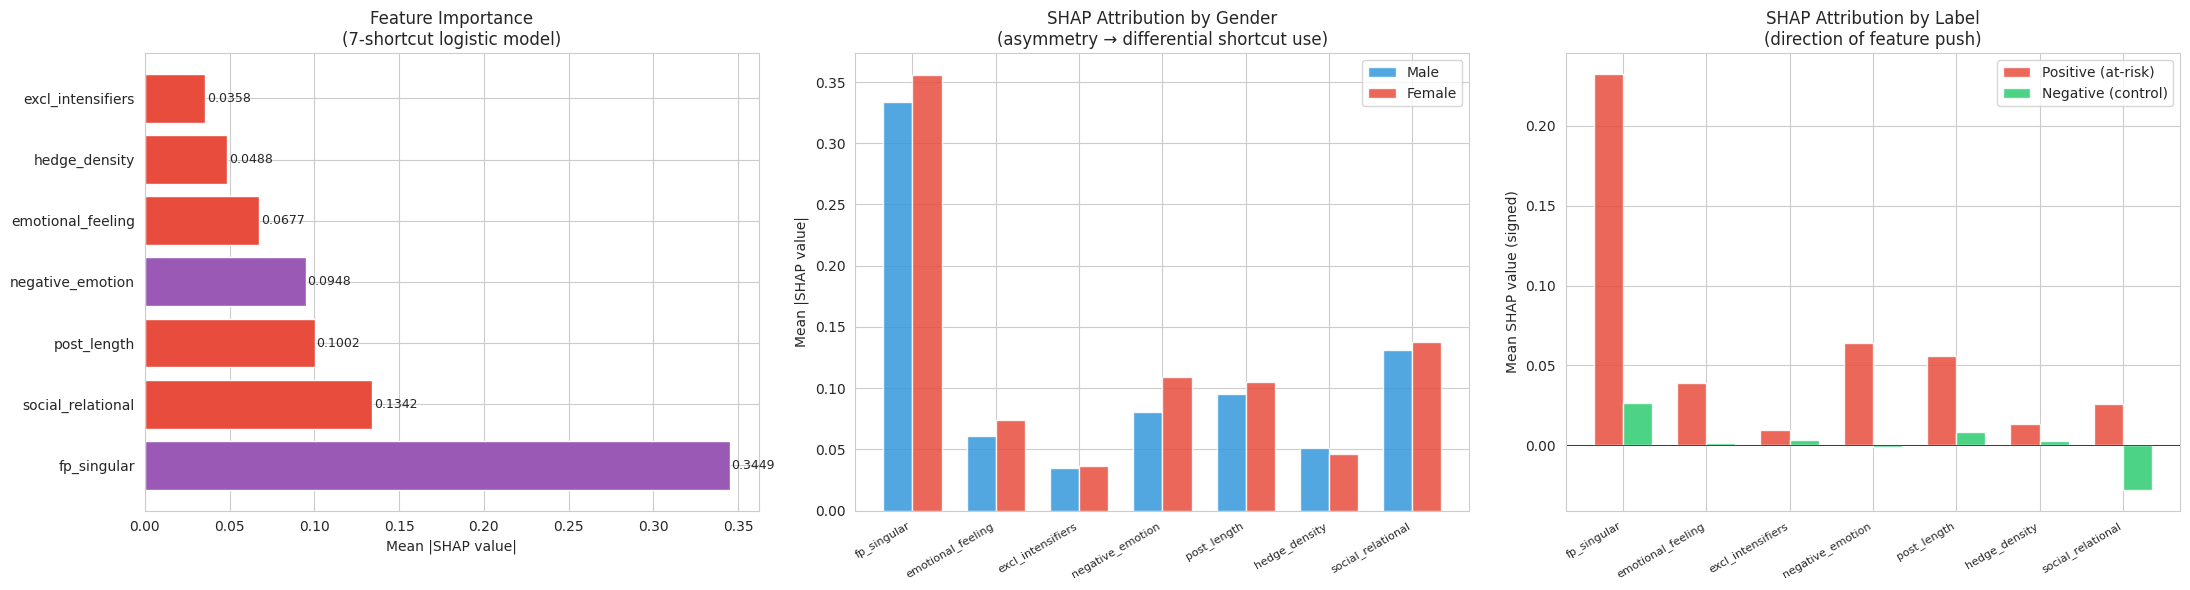

Saved → data/stage2/shap_shortcut_analysis.png


In [24]:
# ── SHAP visualisations ───────────────────────────────────────────────────────
n_short = len(SHORTCUT_FEATURES)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# (A) SHAP bar plot — mean |SHAP| per feature
mean_abs = np.abs(shap_values).mean(axis=0)
order = np.argsort(mean_abs)[::-1]
palette_shap = {'Feminine-coded': '#e74c3c', 'Both (depr + fem)': '#9b59b6'}
bar_colors = [palette_shap.get(SHORTCUT_META[SHORTCUT_FEATURES[i]]['gender'], '#95a5a6') for i in order]
axes[0].barh(range(len(order)), mean_abs[order], color=bar_colors, edgecolor='white')
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels([SHORTCUT_FEATURES[i] for i in order], fontsize=10)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title(f'Feature Importance\n({n_short}-shortcut logistic model)')
for i, idx in enumerate(order):
    axes[0].text(mean_abs[idx] + 0.001, i, f'{mean_abs[idx]:.4f}', va='center', fontsize=9)

# (B) SHAP by gender — are shortcut features used differently for male vs female?
shap_df = pd.DataFrame(shap_values, columns=SHORTCUT_FEATURES)
shap_df['gender'] = df[GENDER_COL].values

male_shap = shap_df[shap_df['gender'] == 'male'][SHORTCUT_FEATURES].abs().mean()
female_shap = shap_df[shap_df['gender'] == 'female'][SHORTCUT_FEATURES].abs().mean()

x = np.arange(n_short)
w = 0.35
axes[1].bar(x - w/2, male_shap.values, w, label='Male', color='#3498db', alpha=0.85)
axes[1].bar(x + w/2, female_shap.values, w, label='Female', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=8, rotation=30, ha='right')
axes[1].set_ylabel('Mean |SHAP value|')
axes[1].set_title('SHAP Attribution by Gender\n(asymmetry → differential shortcut use)')
axes[1].legend()

# (C) SHAP by label — positive vs negative
pos_shap = shap_df[df['binary_label'].values == 1][SHORTCUT_FEATURES].mean()
neg_shap = shap_df[df['binary_label'].values == 0][SHORTCUT_FEATURES].mean()

axes[2].bar(x - w/2, pos_shap.values, w, label='Positive (at-risk)', color='#e74c3c', alpha=0.85)
axes[2].bar(x + w/2, neg_shap.values, w, label='Negative (control)', color='#2ecc71', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(SHORTCUT_FEATURES, fontsize=8, rotation=30, ha='right')
axes[2].set_ylabel('Mean SHAP value (signed)')
axes[2].set_title('SHAP Attribution by Label\n(direction of feature push)')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].legend()

plt.tight_layout()
plt.savefig('data/stage2/shap_shortcut_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/shap_shortcut_analysis.png")

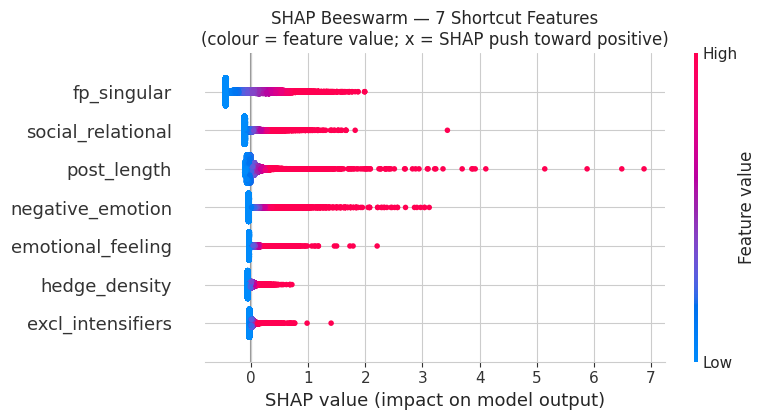

Saved → data/stage2/shap_beeswarm.png


In [25]:
# ── SHAP beeswarm — feature value × SHAP direction ───────────────────────────
# Shows whether HIGH or LOW values of each feature push toward positive label
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(shap_values), explainer.expected_value),
    data=X_short_scaled,
    feature_names=SHORTCUT_FEATURES,
)

fig, ax = plt.subplots(figsize=(12, 6))
shap.plots.beeswarm(shap_explanation, show=False, max_display=len(SHORTCUT_FEATURES))
plt.title(f'SHAP Beeswarm — {len(SHORTCUT_FEATURES)} Shortcut Features\n(colour = feature value; x = SHAP push toward positive)')
plt.tight_layout()
plt.savefig('data/stage2/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/shap_beeswarm.png")

## 2C — Feature Ablation: Quantifying Shortcut Reliance

**Question:** How much does the model rely on each shortcut feature? If we remove it, how much AUC is lost?

**Method:** Train a 14-feature logistic model (baseline), then ablate (zero-out) each shortcut feature one at a time and re-evaluate. Also test removing all 3 simultaneously. The AUC drop quantifies reliance.

Additionally: **gender-stratified ablation** — does removing a shortcut feature hurt performance more for one gender than the other? Asymmetric degradation = gender-biased shortcut.

In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE ABLATION — Remove shortcut features, measure AUC drop
# ══════════════════════════════════════════════════════════════════════════════
ALL_14_FEATURES = [
    'hedge_density', 'fp_singular', 'fp_plural', 'emotional_feeling',
    'social_relational', 'certainty', 'negative_emotion', 'swear_words',
    'excl_intensifiers', 'question_density', 'post_length', 'apology_selfblame',
    'anger', 'body_health',
]

X_all = df[ALL_14_FEATURES].fillna(0).values.astype(float)
y_all = df['binary_label'].values.astype(int)

sc14 = StandardScaler()
X_all_scaled = sc14.fit_transform(X_all)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Baseline — all 14 features
clf_base = LogisticRegression(max_iter=1000, random_state=42)
base_aucs = cross_val_score(clf_base, X_all_scaled, y_all, cv=cv, scoring='roc_auc')
baseline_auc = base_aucs.mean()
print(f"Baseline (14 features): AUC = {baseline_auc:.4f} ± {base_aucs.std():.4f}")

# Single-feature ablation
ablation_results = []
for feat in SHORTCUT_FEATURES:
    feat_idx = ALL_14_FEATURES.index(feat)
    X_abl = X_all_scaled.copy()
    X_abl[:, feat_idx] = 0  # zero-out the feature

    clf_abl = LogisticRegression(max_iter=1000, random_state=42)
    abl_aucs = cross_val_score(clf_abl, X_abl, y_all, cv=cv, scoring='roc_auc')

    drop = baseline_auc - abl_aucs.mean()
    ablation_results.append({
        'ablated': feat,
        'AUC_after': abl_aucs.mean(),
        'AUC_std': abl_aucs.std(),
        'AUC_drop': drop,
        'drop_pct': drop / baseline_auc * 100,
    })
    print(f"  Ablate {feat:20s}: AUC = {abl_aucs.mean():.4f}  (Δ = {drop:+.4f}, {drop/baseline_auc*100:+.2f}%)")

# All 7 shortcut features ablated simultaneously
feat_idxs = [ALL_14_FEATURES.index(f) for f in SHORTCUT_FEATURES]
X_abl_all = X_all_scaled.copy()
X_abl_all[:, feat_idxs] = 0
clf_abl_all = LogisticRegression(max_iter=1000, random_state=42)
abl_all_aucs = cross_val_score(clf_abl_all, X_abl_all, y_all, cv=cv, scoring='roc_auc')
drop_all = baseline_auc - abl_all_aucs.mean()
print(f"\n  Ablate ALL {len(SHORTCUT_FEATURES)} shortcuts: AUC = {abl_all_aucs.mean():.4f}  "
      f"(Δ = {drop_all:+.4f}, {drop_all/baseline_auc*100:+.2f}%)")

ablation_df = pd.DataFrame(ablation_results)
ablation_df

Baseline (14 features): AUC = 0.7090 ± 0.0053
  Ablate fp_singular         : AUC = 0.6953  (Δ = +0.0138, +1.94%)
  Ablate emotional_feeling   : AUC = 0.7069  (Δ = +0.0021, +0.30%)
  Ablate excl_intensifiers   : AUC = 0.7085  (Δ = +0.0005, +0.07%)
  Ablate negative_emotion    : AUC = 0.7074  (Δ = +0.0016, +0.23%)
  Ablate post_length         : AUC = 0.7027  (Δ = +0.0064, +0.90%)
  Ablate hedge_density       : AUC = 0.7086  (Δ = +0.0005, +0.07%)
  Ablate social_relational   : AUC = 0.7022  (Δ = +0.0069, +0.97%)

  Ablate ALL 7 shortcuts: AUC = 0.6451  (Δ = +0.0640, +9.02%)


,ablated,AUC_after,AUC_std,AUC_drop,drop_pct
0,fp_singular,0.695263,0.007274,0.013767,1.941726
1,emotional_feeling,0.706913,0.005320,0.002118,0.298679
2,excl_intensifiers,0.708501,0.005087,0.000530,0.074692
3,negative_emotion,0.707427,0.004579,0.001603,0.226105
4,post_length,0.702667,0.005949,0.006363,0.897414
5,hedge_density,0.708552,0.005072,0.000478,0.067414
6,social_relational,0.702177,0.005440,0.006854,0.966623


Gender-stratified ablation (AUC drop):
gender             female    male  asymmetry
ablated                                     
emotional_feeling  0.0021  0.0004     0.0017
excl_intensifiers -0.0000 -0.0009     0.0009
fp_singular        0.0117  0.0015     0.0102
hedge_density      0.0004  0.0011     0.0007
negative_emotion   0.0023  0.0024     0.0001
post_length        0.0044  0.0090     0.0046
social_relational  0.0073  0.0061     0.0012


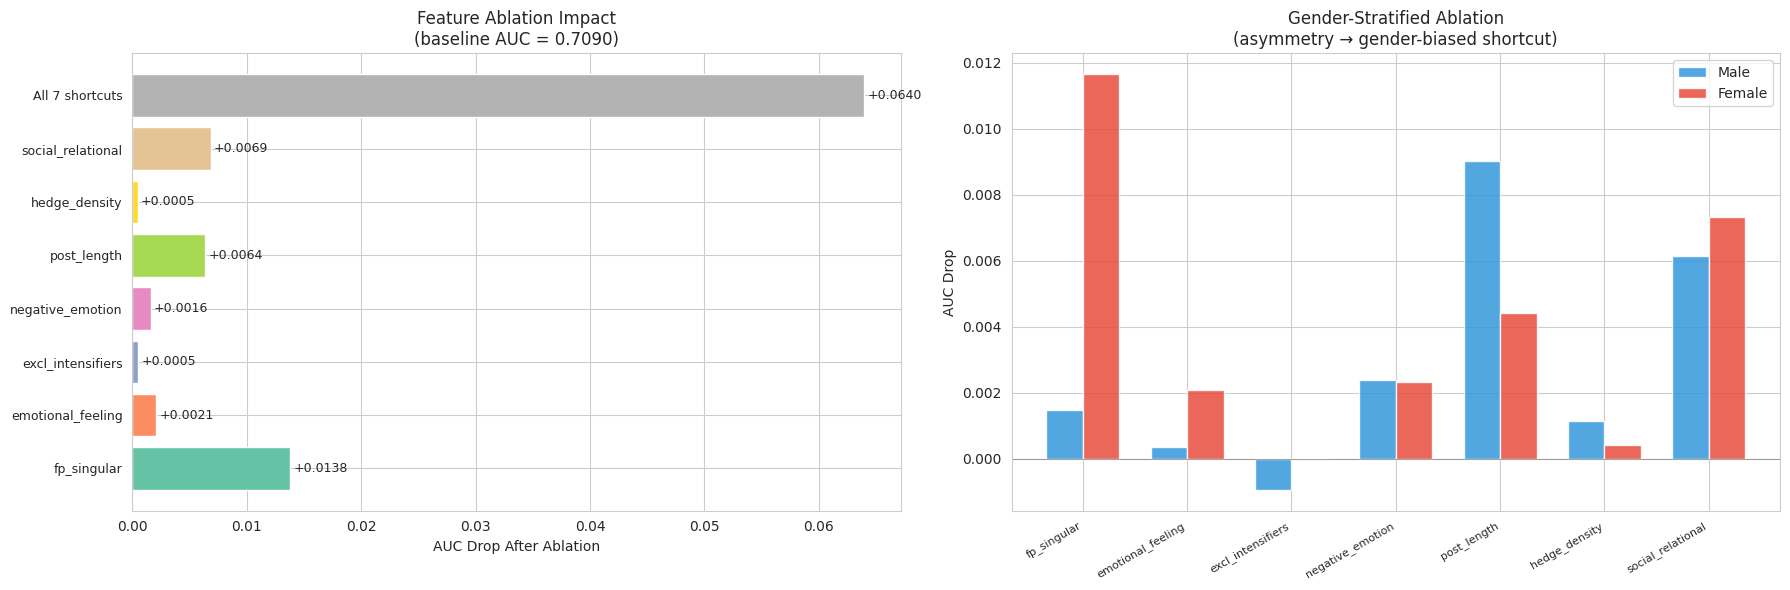

Saved → data/stage2/ablation_analysis.png


In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# GENDER-STRATIFIED ABLATION — Does shortcut removal hurt one gender more?
# ══════════════════════════════════════════════════════════════════════════════
# Train on FULL data, evaluate separately on male & female subsets.
# Asymmetric AUC drop → shortcut is gender-biased.

clf_full = LogisticRegression(max_iter=1000, random_state=42)
clf_full.fit(X_all_scaled, y_all)

# All rows are male/female in this dataset
genders = df[GENDER_COL].values

strat_results = []

for gender in ['male', 'female']:
    g_mask = genders == gender
    X_g = X_all_scaled[g_mask]
    y_g = y_all[g_mask]

    if len(np.unique(y_g)) < 2:
        continue

    # Baseline AUC for this gender
    base_auc_g = roc_auc_score(y_g, clf_full.predict_proba(X_g)[:, 1])

    for feat in SHORTCUT_FEATURES:
        feat_idx = ALL_14_FEATURES.index(feat)
        X_g_abl = X_g.copy()
        X_g_abl[:, feat_idx] = 0
        abl_auc_g = roc_auc_score(y_g, clf_full.predict_proba(X_g_abl)[:, 1])
        drop_g = base_auc_g - abl_auc_g

        strat_results.append({
            'gender': gender,
            'ablated': feat,
            'n_posts': g_mask.sum(),
            'baseline_AUC': base_auc_g,
            'ablated_AUC': abl_auc_g,
            'AUC_drop': drop_g,
            'drop_pct': drop_g / base_auc_g * 100,
        })

strat_df = pd.DataFrame(strat_results)

# Pivot for clear comparison
print("Gender-stratified ablation (AUC drop):")
pivot = strat_df.pivot(index='ablated', columns='gender', values='AUC_drop')
pivot['asymmetry'] = (pivot['male'] - pivot['female']).abs()
print(pivot.round(4).to_string())

# ── Visualization ─────────────────────────────────────────────────────────────
n_short = len(SHORTCUT_FEATURES)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (A) Ablation AUC drops — overall
abl_labels = list(ablation_df['ablated']) + [f'All {n_short} shortcuts']
abl_drops  = list(ablation_df['AUC_drop']) + [drop_all]
cmap = plt.cm.Set2(np.linspace(0, 1, n_short + 1))
colors_abl = [cmap[i] for i in range(len(abl_labels))]

axes[0].barh(range(len(abl_labels)), abl_drops, color=colors_abl, edgecolor='white')
axes[0].set_yticks(range(len(abl_labels)))
axes[0].set_yticklabels(abl_labels, fontsize=9)
axes[0].set_xlabel('AUC Drop After Ablation')
axes[0].set_title(f'Feature Ablation Impact\n(baseline AUC = {baseline_auc:.4f})')
axes[0].axvline(0, color='grey', linewidth=0.5)
for i, d in enumerate(abl_drops):
    axes[0].text(max(d, 0) + 0.0003, i, f'{d:+.4f}', va='center', fontsize=9)

# (B) Gender-stratified ablation
x = np.arange(n_short)
w = 0.35
male_drops = strat_df[strat_df['gender']=='male'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values
female_drops = strat_df[strat_df['gender']=='female'].set_index('ablated').loc[SHORTCUT_FEATURES, 'AUC_drop'].values

axes[1].bar(x - w/2, male_drops, w, label='Male', color='#3498db', alpha=0.85)
axes[1].bar(x + w/2, female_drops, w, label='Female', color='#e74c3c', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(SHORTCUT_FEATURES, fontsize=8, rotation=30, ha='right')
axes[1].set_ylabel('AUC Drop')
axes[1].set_title('Gender-Stratified Ablation\n(asymmetry → gender-biased shortcut)')
axes[1].legend()
axes[1].axhline(0, color='grey', linewidth=0.5)

plt.tight_layout()
plt.savefig('data/stage2/ablation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/stage2/ablation_analysis.png")

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# STAGE 2 SUMMARY — Save all results
# ══════════════════════════════════════════════════════════════════════════════
probe_df.to_csv('data/stage2/stage2_probing_results.csv', index=False)
ablation_df.to_csv('data/stage2/stage2_ablation_results.csv', index=False)
strat_df.to_csv('data/stage2/stage2_gender_stratified_ablation.csv', index=False)

# Save SHAP values for downstream use
np.save('data/stage2/stage2_shap_values.npy', shap_values)

print("=" * 60)
print("STAGE 2 SUMMARY — SHORTCUT AUDITING")
print("=" * 60)

print(f"\n(A) PROBING — Does frozen DistilRoBERTa [CLS] encode shortcuts?")
for _, row in probe_df.iterrows():
    encoded = "YES" if row['probe_AUC_median_split'] > 0.55 else "weak/NO"
    print(f"  {row['feature']:20s}  AUC={row['probe_AUC_median_split']:.3f}  R²={row['probe_R2']:.4f}  → {encoded}")
print(f"  {'gender (m/f)':20s}  AUC={aucs_g.mean():.3f}")
print(f"  {'binary_label':20s}  AUC={aucs_l.mean():.3f}")

print(f"\n(B) SHAP — Feature attribution ({len(SHORTCUT_FEATURES)}-shortcut logistic model):")
for feat, val in sorted(zip(SHORTCUT_FEATURES, mean_abs_shap), key=lambda x: -x[1]):
    pct = val / mean_abs_shap.sum() * 100
    print(f"  {feat:20s}  mean|SHAP|={val:.4f}  ({pct:.1f}% of total)")

print(f"\n(C) ABLATION — AUC impact of removing shortcuts:")
print(f"  Baseline (14 features): AUC = {baseline_auc:.4f}")
for _, row in ablation_df.iterrows():
    print(f"  Remove {row['ablated']:20s}: AUC = {row['AUC_after']:.4f}  (Δ = {row['AUC_drop']:+.4f})")
print(f"  Remove ALL {len(SHORTCUT_FEATURES)}:             AUC = {abl_all_aucs.mean():.4f}  (Δ = {drop_all:+.4f})")

print(f"\n(D) GENDER-STRATIFIED ABLATION — Asymmetric impact:")
for feat in SHORTCUT_FEATURES:
    m_drop = strat_df[(strat_df['ablated']==feat) & (strat_df['gender']=='male')]['AUC_drop'].values[0]
    f_drop = strat_df[(strat_df['ablated']==feat) & (strat_df['gender']=='female')]['AUC_drop'].values[0]
    asym = abs(m_drop - f_drop)
    bias_dir = "→ male" if m_drop > f_drop else "→ female"
    print(f"  {feat:20s}  male Δ={m_drop:+.4f}  female Δ={f_drop:+.4f}  asymmetry={asym:.4f} {bias_dir}")

print(f"\nSaved:")
print(f"  → data/stage2/stage2_probing_results.csv")
print(f"  → data/stage2/stage2_ablation_results.csv")
print(f"  → data/stage2/stage2_gender_stratified_ablation.csv")
print(f"  → data/stage2/stage2_shap_values.npy")
print(f"  → data/stage2/probing_results.png")
print(f"  → data/stage2/shap_shortcut_analysis.png")
print(f"  → data/stage2/shap_beeswarm.png")
print(f"  → data/stage2/ablation_analysis.png")

STAGE 2 SUMMARY — SHORTCUT AUDITING

(A) PROBING — Does frozen DistilRoBERTa [CLS] encode shortcuts?
  fp_singular           AUC=0.976  R²=0.8555  → YES
  emotional_feeling     AUC=0.904  R²=0.3778  → YES
  excl_intensifiers     AUC=0.882  R²=0.5957  → YES
  negative_emotion      AUC=0.896  R²=0.2701  → YES
  post_length           AUC=0.998  R²=0.4412  → YES
  hedge_density         AUC=0.832  R²=0.4060  → YES
  social_relational     AUC=0.923  R²=0.5550  → YES
  gender (m/f)          AUC=0.959
  binary_label          AUC=0.798

(B) SHAP — Feature attribution (7-shortcut logistic model):
  fp_singular           mean|SHAP|=0.3449  (41.7% of total)
  social_relational     mean|SHAP|=0.1342  (16.2% of total)
  post_length           mean|SHAP|=0.1002  (12.1% of total)
  negative_emotion      mean|SHAP|=0.0948  (11.5% of total)
  emotional_feeling     mean|SHAP|=0.0677  (8.2% of total)
  hedge_density         mean|SHAP|=0.0488  (5.9% of total)
  excl_intensifiers     mean|SHAP|=0.0358  (4.3%

Stage 2 Results Interpretation
Why [CLS] from unfinetuned DistilRoBERTa?
This is a diagnostic probe — not the model you'd deploy. The logic is:

Pre-training encodes linguistic style. A language model trained on generic web text learns representations that capture stylistic features (pronoun use, emotionality, hedging, etc.) as a byproduct of language modeling.
If shortcuts are already recoverable before fine-tuning, the model has a "head start" on exploiting them. When you later fine-tune on mental health classification, the model can cheaply leverage these pre-existing gender-correlated features instead of learning deeper clinical signal.
This establishes a ceiling of concern. If the frozen model couldn't recover shortcuts, there'd be less worry about fine-tuning amplifying them.
(A) Probing — All 7 shortcuts deeply encoded
Every shortcut feature is recoverable with AUC 0.83–0.98, and gender itself at 0.959. This means the representation space is structured around exactly the features we flagged as gender-correlated shortcuts. The mental health label probe (AUC 0.798) confirms clinical signal also exists, but it's entangled with these shortcut dimensions.

(B) SHAP — fp_singular dominates
The 7-shortcut logistic model achieves AUC = 0.6925. SHAP decomposition shows:

fp_singular accounts for 41.7% of all SHAP mass — "I/me/my" is the single biggest driver
social_relational (16.2%) and post_length (12.1%) are the next largest
The gender panel shows clear asymmetry: female posts get larger SHAP contributions from fp_singular and emotional_feeling, confirming differential feature reliance by gender
(C) Ablation — Removing all 7 drops AUC by 9%
Baseline 14-feature AUC: 0.709
After ablating all 7 shortcuts: 0.645 (Δ = −0.064, −9.0%)
Individually, fp_singular causes the largest drop (−0.014), followed by social_relational (−0.007) and post_length (−0.006)
This means ~9% of the model's discriminative power comes specifically from gender-correlated features
(D) Gender-stratified ablation — fp_singular is asymmetric
The most striking finding: removing fp_singular drops AUC by 0.012 for female posts but only 0.002 for male posts (asymmetry = 0.010). This confirms fp_singular is a female-biased shortcut — the model relies on first-person pronoun density more for classifying women than men. Similarly, post_length shows the reverse pattern (male Δ = 0.009 > female Δ = 0.004), suggesting longer posts are a more important signal for male classification.